In [ ]:
Task 1: Data Cleaning and Formatting

In [30]:
# checking the dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\romia\Downloads\PYTHON PROJECT-Financial Risk Analysis with Python- JP Morgan\jp_morgan.csv")
print(df.shape)
print(df.head())
print(df.info())
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

(800, 15)
   TransactionID CustomerID AccountID AccountType TransactionType  \
0              3   CUST2412  ACC80131        Loan      Withdrawal   
1             32   CUST1467  ACC74631     Current      Withdrawal   
2              9   CUST2699  ACC39482        Loan      Withdrawal   
3             42   CUST9535  ACC82947     Current      Withdrawal   
4            166   CUST7459  ACC39500      Credit         Payment   

         Product    Firm Region    Manager TransactionDate  TransactionAmount  \
0  Personal Loan  Firm C   West  Manager 3      06-08-2023        33759.69057   
1      Home Loan  Firm D  North  Manager 2      08-11-2023        69319.19933   
2    Credit Card  Firm D   West  Manager 4      15-05-2024        42831.48483   
3      Home Loan  Firm A  South  Manager 4      30-04-2023        70903.79697   
4      Home Loan  Firm D  South  Manager 4      16-02-2023        21948.97355   

   AccountBalance  RiskScore  CreditRating  TenureMonths  
0    126486.40830   0.225824 

In [31]:
# checking null values and summary statistics
print(df.isnull().sum())

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64


In [32]:
# remove special characters & convert to numeric
financial_cols = ["TransactionAmount", "AccountBalance", "RiskScore"]
for col in financial_cols:
    df[col] = (
        df[col]
        .astype(str)                 # convert to string
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("₹", "", regex=False)
        .str.strip()
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [33]:
# validate and format dates
df["TransactionDate"] = (
    df["TransactionDate"]
    .astype(str)
    .str.replace("-", "/", regex=False)
)
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)

In [34]:
# categories standardization
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()
df['AccountType'] = df['AccountType'].str.lower().str.strip()

In [35]:
print(df.dtypes)
df.head()

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
dtype: object


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,loan,withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,current,withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,loan,withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,current,withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,credit,payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13


In [36]:
# Check Duplicate Rows
print(df.duplicated().sum())

0


In [ ]:
Task 2: Descriptive Transactional Analysis

In [40]:
## monthly and yearly summaries
df['Month'] = df['TransactionDate'].dt.month

df['Year'] = df['TransactionDate'].dt.year

In [41]:
## Monthly Credit & Debit Summary
monthly_summary = df.groupby(['Month', 'TransactionType'])['TransactionAmount'].sum()
print(monthly_summary)

Month  TransactionType
1      deposit            9.222718e+05
       payment            1.440460e+06
       transfer           6.549424e+05
       withdrawal         1.130474e+06
2      deposit            1.295505e+06
       payment            1.521112e+06
       transfer           1.043521e+06
       withdrawal         8.580448e+05
3      deposit            1.240716e+06
       payment            1.430582e+06
       transfer           1.476454e+06
       withdrawal         1.479368e+06
4      deposit            9.483745e+05
       payment            1.244681e+06
       transfer           8.236942e+05
       withdrawal         1.553889e+06
5      deposit            8.412837e+05
       payment            1.053012e+06
       transfer           1.248925e+06
       withdrawal         1.095044e+06
6      deposit            1.060592e+06
       payment            5.863647e+05
       transfer           1.047924e+06
       withdrawal         8.235723e+05
7      deposit            7.939716e+05
  

In [42]:
## Yearly Summary
yearly_summary = df.groupby(['Year', 'TransactionType'])['TransactionAmount'].sum()
print(yearly_summary)

Year  TransactionType
2023  deposit            8.225787e+06
      payment            6.974170e+06
      transfer           6.395137e+06
      withdrawal         8.017619e+06
2024  deposit            2.238946e+06
      payment            3.100943e+06
      transfer           2.711474e+06
      withdrawal         3.205223e+06
Name: TransactionAmount, dtype: float64


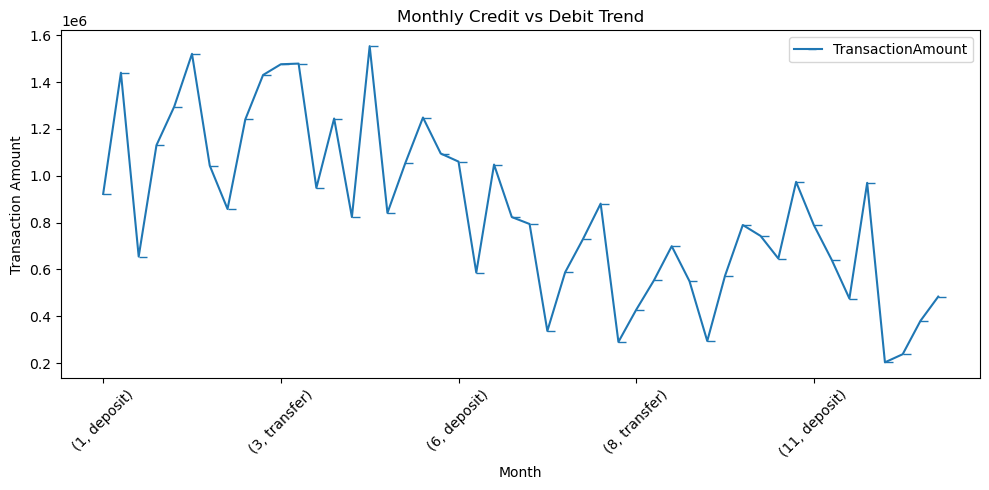

In [59]:
## Plot Credit vs Debit Trend
plt.figure(figsize=(10, 5))

monthly_summary.plot(kind='line', figsize=(10,5), marker=1)
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
## Top and Bottom performing accounts based on net inflow.
account_flow = df.groupby('AccountID')['TransactionAmount'].sum()
top_accounts = account_flow.sort_values(ascending=False).head()
bottom_accounts = account_flow.sort_values().head()
top_accounts, bottom_accounts

(AccountID
 ACC42710    539494.876440
 ACC45907    532556.635574
 ACC81631    483854.558670
 ACC32627    471468.023823
 ACC18140    458219.210460
 Name: TransactionAmount, dtype: float64,
 AccountID
 ACC12334    15159.688345
 ACC50439    24088.157284
 ACC65144    30425.901148
 ACC28305    32162.348245
 ACC43771    32819.585640
 Name: TransactionAmount, dtype: float64)

In [71]:
print(net_inflow.sort_values().head())

Series([], Name: TransactionAmount, dtype: float64)


In [72]:
# Identify dormant / inactive accounts (≥ 2 months gap)

df_sorted = df.sort_values(["AccountID", "TransactionDate"])
df_sorted["PrevTransactionDate"] = df_sorted.groupby("AccountID")["TransactionDate"].shift(1)
df_sorted["GapDays"] = (
    df_sorted["TransactionDate"] - df_sorted["PrevTransactionDate"]
).dt.days
dormant_accounts = df_sorted[df_sorted["GapDays"] >= 60]["AccountID"].unique()
len(dormant_accounts), dormant_accounts[:10]

(164,
 array(['ACC10996', 'ACC11062', 'ACC11188', 'ACC11285', 'ACC12182',
        'ACC12334', 'ACC13357', 'ACC15228', 'ACC15359', 'ACC15671'],
       dtype=object))

In [ ]:
Task 3: Customer Profile Building

In [81]:
# Transaction Frequency
frequency = df.groupby(
    'AccountID'
)['TransactionType'].count()

print(frequency)

AccountID
ACC10117    1
ACC10996    4
ACC11062    4
ACC11188    3
ACC11285    6
           ..
ACC97225    5
ACC97411    6
ACC99117    6
ACC99409    2
ACC99549    5
Name: TransactionType, Length: 194, dtype: int64


In [98]:
# Assign activity levels

## Rubric: High Activity → More than 50 transactions,Medium Activity → 20 to 50,
## Low Activity → Less than 20

def activity_level(x):
    if x > 50:
        return "High"
    elif x >= 20:
        return "Medium"
    else:
        return "Low"

activity = frequency.apply(activity_level)

print(activity)

AccountID
ACC10117    Low
ACC10996    Low
ACC11062    Low
ACC11188    Low
ACC11285    Low
           ... 
ACC97225    Low
ACC97411    Low
ACC99117    Low
ACC99409    Low
ACC99549    Low
Name: TransactionType, Length: 194, dtype: object


In [104]:
## Segment customers by average balance and transaction volume.
profile = df.groupby('AccountID').agg({'TransactionAmount': 'mean','AccountBalance': 'mean'})
profile.head()

,TransactionAmount,AccountBalance
AccountID,,
ACC10117,56317.920060,90780.256640
ACC10996,55939.383629,64046.568590
ACC11062,66482.145835,62784.100737
ACC11188,38852.651500,80558.926400
ACC11285,62198.254735,95745.546255


In [108]:
# Create profiles for.
customer_profile = profile.copy()
customer_profile['TransactionFrequency'] = frequency
customer_profile['ActivityLevel'] = activity
customer_profile.head()

,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,
ACC10117,56317.920060,90780.256640,1,Low
ACC10996,55939.383629,64046.568590,4,Low
ACC11062,66482.145835,62784.100737,4,Low
ACC11188,38852.651500,80558.926400,3,Low
ACC11285,62198.254735,95745.546255,6,Low


In [109]:
## High Net Inflow Accounts
high_inflow_accounts = customer_profile[
customer_profile['TransactionAmount'] > customer_profile['TransactionAmount'].quantile(0.75)]
high_inflow_accounts.head()

,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,
ACC11062,66482.145835,62784.100737,4,Low
ACC11285,62198.254735,95745.546255,6,Low
ACC18140,65459.887209,68418.205836,7,Low
ACC22255,83228.936925,48149.863135,2,Low
ACC24070,65018.226010,64984.452900,5,Low


In [111]:
## High‑Frequency, Low‑Balance Accounts

high_freq_low_bal = customer_profile[
(customer_profile['TransactionFrequency'] > customer_profile['TransactionFrequency'].quantile(0.75)) &
(customer_profile['AccountBalance'] < customer_profile['AccountBalance'].quantile(0.25))]
high_freq_low_bal.head()

,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,
ACC15671,45236.980554,51776.654462,6,Low
ACC39500,50417.627706,57445.826828,6,Low
ACC45907,53255.663557,53323.047352,10,Low
ACC53466,54496.739869,57309.855371,7,Low
ACC57700,66099.426685,53388.047296,6,Low


In [114]:
## Negative or Near‑Zero Balance Accounts
negative_balance_accounts = customer_profile[
customer_profile['AccountBalance'] <= 5000
]
negative_balance_accounts.head()

,TransactionAmount,AccountBalance,TransactionFrequency,ActivityLevel
AccountID,,,,


In [ ]:
Task 4: Financial Risk Identification

In [116]:
## Large Withdrawals
large_withdrawals = df[
(df['TransactionType'] == 'debit') &
(df['TransactionAmount'] > df['TransactionAmount'].quantile(0.90))]
large_withdrawals.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year


In [117]:
# Balance Volatility (Risk Stability)

balance_volatility = df.groupby("AccountID")["AccountBalance"].std().reset_index()
balance_volatility.rename(columns={"AccountBalance": "BalanceStdDev"}, inplace=True)

balance_volatility.head()

,AccountID,BalanceStdDev
0,ACC10117,NaN
1,ACC10996,30390.798000
2,ACC11062,37598.383500
3,ACC11188,33781.833882
4,ACC11285,42139.172552


In [121]:
## Z-score methods to detect anomalies.

df['zscore'] = stats.zscore(df['TransactionAmount'])
anomaly = df[
    (df['zscore'] > 3) | (df['zscore'] < -3)]
print(anomaly)

     TransactionID CustomerID AccountID AccountType TransactionType  \
53             178   CUST1189  ACC50439     savings         deposit   
242             86   CUST7855  ACC95164     savings         payment   
397             51   CUST1497  ACC88074     current        transfer   
727            163   CUST1747  ACC92104     savings         deposit   

             Product    Firm Region    Manager TransactionDate  \
53   Savings Account  Firm D   East  Manager 1      2024-06-16   
242        Home Loan  Firm C  North  Manager 3      2023-10-26   
397      Mutual Fund  Firm B   East  Manager 3      2024-03-05   
727  Savings Account  Firm A   West  Manager 1      2023-08-06   

     TransactionAmount  AccountBalance  RiskScore  CreditRating  TenureMonths  \
53        -60979.07348     57916.06101   0.160988           655            17   
242       143067.18460     73627.79044   0.752617           582           226   
397       -45352.95439     96125.56424  -0.203847           668       

In [125]:
## Highlight customers with irregular or suspicious transaction behavior

high_vol_threshold = balance_volatility["BalanceStdDev"].quantile(0.90)

high_vol_accounts = balance_volatility[
    balance_volatility["BalanceStdDev"] >= high_vol_threshold
]["AccountID"]

suspicious_accounts = set(large_withdrawals["AccountID"]) \
    .union(set(high_vol_accounts)) \
    .union(set(anomalies["AccountID"]))

list(suspicious_accounts)[:10]

['ACC51971',
 'ACC57872',
 'ACC28295',
 'ACC88074',
 'ACC57516',
 'ACC23736',
 'ACC95164',
 'ACC33287',
 'ACC66086',
 'ACC77638']

In [ ]:
Task 5: Visualisation

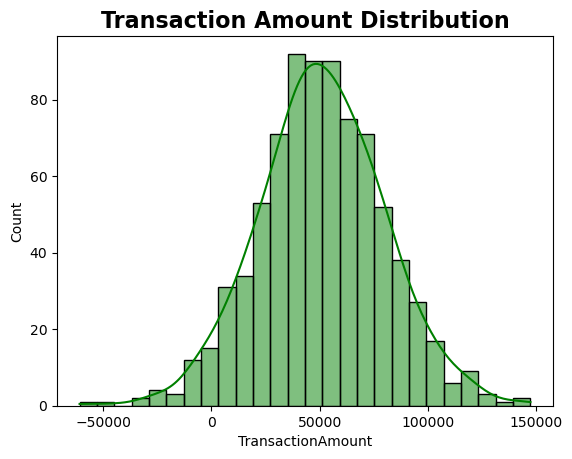

In [144]:
## Distribution Plot
sns.histplot(df['TransactionAmount'], kde=True, color="green")
plt.title("Transaction Amount Distribution", fontsize=16, fontweight='bold', color="black")
plt.show()

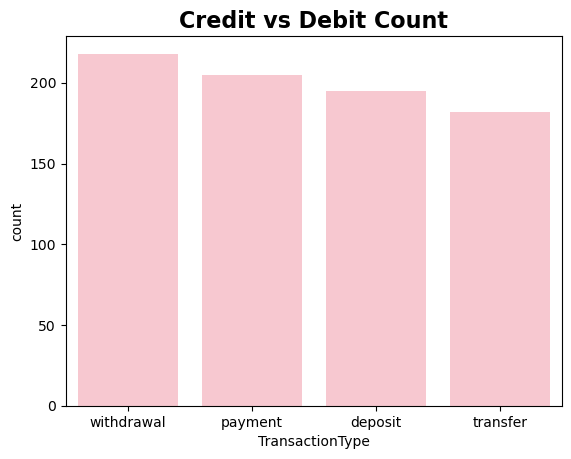

In [143]:
## Count Plot
sns.countplot( x='TransactionType', data=df, color="pink")
plt.title("Credit vs Debit Count", fontsize=16, fontweight='bold', color="black")
plt.show()

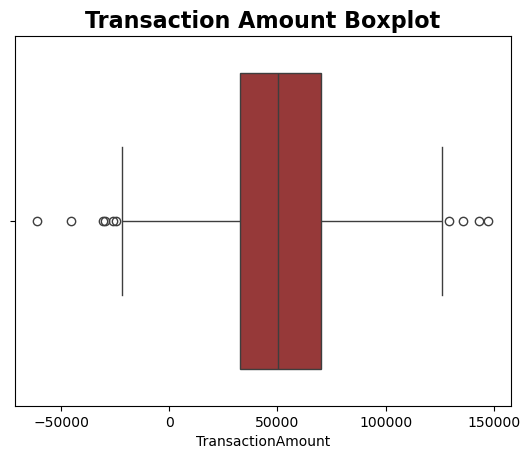

In [142]:
## Boxplot
sns.boxplot(x=df['TransactionAmount'], color="brown")
plt.title("Transaction Amount Boxplot",fontsize=16, fontweight='bold', color="black")
plt.show()

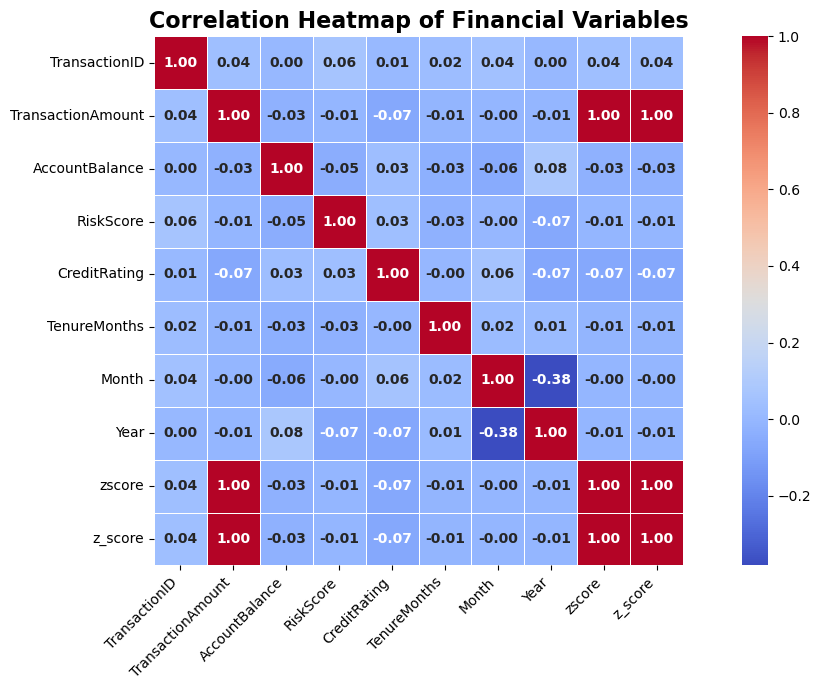

In [150]:
## Correlation Heatmap

plt.figure(figsize=(12, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,linecolor='white',cbar=True,square=True,annot_kws={"size": 10, "weight": "bold"}
)
plt.title(
    "Correlation Heatmap of Financial Variables",fontsize=16,fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
Task 6: Hypothesis Testing

In [160]:
from scipy import stats
## Calculate Total Transaction Volume per Account
transaction_volume = df.groupby('AccountID')['TransactionAmount'].sum()
print(transaction_volume.head())

AccountID
ACC10117     56317.920060
ACC10996    223757.534516
ACC11062    265928.583340
ACC11188    116557.954500
ACC11285    373189.528410
Name: TransactionAmount, dtype: float64


In [161]:
## Create High-Volume and Low-Volume Groups-Using median as threshold.

median_volume = transaction_volume.median()
high_volume_accounts = transaction_volume[
    transaction_volume > median_volume].index
low_volume_accounts = transaction_volume[
    transaction_volume <= median_volume].index

In [164]:
## Extract Average Balance of Both Groups
high_balance = df[df['AccountID'].isin(high_volume_accounts)]['AccountBalance']
low_balance = df[df['AccountID'].isin(low_volume_accounts)]['AccountBalance']

In [169]:
## T-Test
t_stat, p_value = stats.ttest_ind(high_balance,low_balance,equal_var=False)
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.4428478087942492
P-Value: 0.6580598081576354


In [170]:
## Interpretation
if p_value < 0.05:
    print("Reject H0")
    print("High-volume accounts have significantly different average balances.")
else:
    print("Fail to Reject H0")
    print("No significant difference in balances.")

Fail to Reject H0
No significant difference in balances.


In [ ]:
Task 7

https://drive.google.com/drive/folders/1A5SYERDcnqkQTPMlQbSpTgU4Jw5YQ-vO?usp=sharing